# ML-08 — Capstone Modeling Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/faheem-danish/internship-starter-1/blob/main/work/notebooks/w05_model.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [21]:
import os
import pandas as pd
from google.colab import userdata
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression


token = userdata.get("HF_TOKEN")
print("Token loaded:", token is not None)

Token loaded: True


In [5]:
from huggingface_hub import hf_hub_download

march_file = hf_hub_download(
    repo_id="FlyRank/internship-warehouse",
    repo_type="dataset",
    filename="fact_content_daily_performance/month=2026-03/data_0.parquet",
    token=token
)

print("March file:", march_file)

March file: /root/.cache/huggingface/hub/datasets--FlyRank--internship-warehouse/snapshots/50cbf7c3909d07be4d1b5906b4d09e882e5acbf2/fact_content_daily_performance/month=2026-03/data_0.parquet


In [6]:
march_df = pd.read_parquet(march_file)

print("Shape:", march_df.shape)
print(
    "Date range:",
    march_df["report_date"].min(),
    "to",
    march_df["report_date"].max()
)

Shape: (9841378, 30)
Date range: 2026-03-01 to 2026-03-31


In [7]:
print("Dataframe shape:", march_df.shape)

print("\nColumns:")
print(march_df.columns.tolist())

print("\nUnique clients:",
      march_df["client_hash_id"].nunique())

print("Unique content:",
      march_df["content_hash_id"].nunique())

Dataframe shape: (9841378, 30)

Columns:
['report_date', 'client_hash_id', 'content_hash_id', 'client_has_gsc', 'client_has_ga4', 'gsc_data_available', 'ga4_data_available', 'gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'gsc_avg_position', 'ga4_pageviews', 'ga4_sessions', 'ga4_users', 'ga4_engaged_sessions', 'ga4_total_engagement_sec', 'sessions_organic', 'sessions_direct', 'sessions_referral', 'sessions_social', 'sessions_paid', 'sessions_ai', 'ai_chatgpt', 'ai_perplexity', 'ai_gemini', 'ai_copilot', 'ai_claude', 'ai_meta', 'ai_other', 'scroll_events']

Unique clients: 55
Unique content: 331437


In [8]:
duplicates = (
    march_df
    .groupby(
        ["report_date", "client_hash_id", "content_hash_id"]
    )
    .size()
    .reset_index(name="n")
)

print("Duplicate grain rows:", (duplicates["n"] > 1).sum())
print("Maximum rows per grain:", duplicates["n"].max())

Duplicate grain rows: 0
Maximum rows per grain: 1


## 1. Method choice and why

*Which method from the toolkit, and why it fits your lane.*
Method choice

My lane is prioritizing content items for a refresh_review action. That is a supervised ranking (yes/no prioritization) problem, not a clustering problem. I will compare two learned methods against my Week-4 rule baseline:
Logistic Regression — simple, fast, and interpretable. The coefficients directly show directional relationships between search-performance signals and the baseline’s eligibility rule.
Random Forest — a constrained tree ensemble (max depth 8, min samples leaf 20) to test whether nonlinear interactions (e.g., position thresholds combined with CTR patterns) improve ranking without rewarding complexity for its own sake.
Evaluation: Precision@20 and Precision@50, because the operational question is not “what is the overall accuracy?” but “which items should be reviewed first?”
Limitation (honesty): The target eligible is generated by the Week-4 baseline rule (impressions >= 500 and avg_position >= 11), not an independently observed business outcome. Therefore, model performance measures agreement with the transparent baseline rather than true refresh success. I do not use eligible, score, reason_code, action, or rank as model features, because they would leak the baseline decision into the model.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. Split design

*Grouped by client? Time-aware? Say why this split is honest for your question.*
Split design

I use a client-grouped train/test split (GroupShuffleSplit, 80/20). Clients — not individual rows — are assigned to training or testing. This prevents client-level leakage: a model should not “peek” at patterns from a client in training and then be evaluated on the same client in test. This better reflects how the system would perform on an unseen client.
I fix random_state=42 so the split is fully reproducible.
Before splitting, I aggregate the raw 9.8M page-day observations to one row per client + content item for the March decision window. Training on repeated daily rows for the same content item would inflate apparent performance and distort the ranking.

In [24]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ------------------------------------------------------------------
# Build modeling grain: one row per client + content for March
# ------------------------------------------------------------------
model_df = march_df.copy()

# Map warehouse names to the baseline feature names
model_df["impressions"] = pd.to_numeric(model_df["gsc_impressions"], errors="coerce").fillna(0)
model_df["clicks"]     = pd.to_numeric(model_df["gsc_clicks"],     errors="coerce").fillna(0)
model_df["avg_position"] = pd.to_numeric(model_df["gsc_avg_position"], errors="coerce")

# Daily CTR
model_df["ctr_pct"] = np.where(
    model_df["impressions"] > 0,
    model_df["clicks"] / model_df["impressions"] * 100,
    0
)

# Aggregate daily rows → one content item per client
model_df = (
    model_df
    .groupby(["client_hash_id", "content_hash_id"], as_index=False)
    .agg(
        impressions=("impressions", "sum"),
        clicks=("clicks", "sum"),
        avg_position=("avg_position", "mean")
    )
)

# Recalculate CTR at the content level
model_df["ctr_pct"] = np.where(
    model_df["impressions"] > 0,
    model_df["clicks"] / model_df["impressions"] * 100,
    0
)

print("Modeling rows:", len(model_df))
print("Unique clients:", model_df["client_hash_id"].nunique())
print("Unique content:", model_df["content_hash_id"].nunique())
display(model_df.head())

# ------------------------------------------------------------------
# Recreate Week-4 baseline EXACTLY
# ------------------------------------------------------------------
model_df["eligible"] = (
    (model_df["impressions"] >= 500) &
    (model_df["avg_position"] >= 11)
)

position_factor = np.where(model_df["avg_position"] >= 21, 1.5, 1.0)
model_df["baseline_score"] = model_df["impressions"] * position_factor
model_df["baseline_action"] = np.where(
    model_df["eligible"], "refresh_review", "no_action"
)

print("\nBaseline refresh candidates:", model_df["eligible"].sum())
print("Baseline eligibility rate:", round(model_df["eligible"].mean(), 4))

# ------------------------------------------------------------------
# Features and target
# ------------------------------------------------------------------
feature_cols = ["impressions", "clicks", "avg_position", "ctr_pct"]
X = model_df[feature_cols].copy()
y = model_df["eligible"].astype(int)

print("\nFeatures:", feature_cols)
print("X shape:", X.shape)
print("Missing values in X:\n", X.isna().sum())
print("Positive rate:", round(y.mean(), 4))

# ------------------------------------------------------------------
# Client-grouped split
# ------------------------------------------------------------------
groups = model_df["client_hash_id"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_clients = set(model_df.iloc[train_idx]["client_hash_id"])
test_clients  = set(model_df.iloc[test_idx]["client_hash_id"])

print("\nTraining rows:", len(X_train), "  Clients:", len(train_clients))
print("Testing rows: ", len(X_test), "  Clients:", len(test_clients))
print("Client overlap:", len(train_clients & test_clients))  # should be 0

Modeling rows: 331437
Unique clients: 55
Unique content: 331437


,client_hash_id,content_hash_id,impressions,clicks,avg_position,ctr_pct
0,client_0797ff3a1fc9a6a5,content_004e9c4c32e88631,0,0,NaN,0.0
1,client_0797ff3a1fc9a6a5,content_0236ef736698e17c,0,0,NaN,0.0
2,client_0797ff3a1fc9a6a5,content_025f6cfd3c298870,0,0,NaN,0.0
3,client_0797ff3a1fc9a6a5,content_0263d5f9b7a2ecd4,1,0,9.0,0.0
4,client_0797ff3a1fc9a6a5,content_02752c6c1c60161f,0,0,NaN,0.0



Baseline refresh candidates: 21143
Baseline eligibility rate: 0.0638

Features: ['impressions', 'clicks', 'avg_position', 'ctr_pct']
X shape: (331437, 4)
Missing values in X:
 impressions          0
clicks               0
avg_position    154699
ctr_pct              0
dtype: int64
Positive rate: 0.0638

Training rows: 300880   Clients: 44
Testing rows:  30557   Clients: 11
Client overlap: 0


## 3. Train + compare vs my baseline

*Same data, same metric, same split as your Week-4 baseline. Show the table.*
I train both models on the training clients and evaluate on the held-out test clients using the same Precision@K metric for all three methods (baseline rule, Logistic Regression, Random Forest). The base rate is included as a sanity check.

In [26]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ------------------------------------------------------------------
# Logistic Regression (with median imputation + scaling)
# ------------------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logistic_model.fit(X_train, y_train)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]
print("Logistic Regression trained successfully.")

# ------------------------------------------------------------------
# Random Forest (controlled, not overgrown)
# ------------------------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
print("Random Forest trained successfully.")

# ------------------------------------------------------------------
# Precision@K helper
# ------------------------------------------------------------------
def precision_at_k(scores, labels, k):
    scores = np.asarray(scores)
    labels = np.asarray(labels)
    order = np.argsort(-scores)
    return labels[order[:k]].mean()

# ------------------------------------------------------------------
# Comparison table: same test set, same metric
# ------------------------------------------------------------------
baseline_test_scores = model_df.iloc[test_idx]["baseline_score"].values
test_labels = y_test.values

results = []
for name, scores in [
    ("Week-4 baseline", baseline_test_scores),
    ("Logistic Regression", logistic_prob),
    ("Random Forest", rf_prob)
]:
    results.append({
        "method": name,
        "precision@20":  round(precision_at_k(scores, test_labels, 20), 4),
        "precision@50":  round(precision_at_k(scores, test_labels, 50), 4),
        "precision@100": round(precision_at_k(scores, test_labels, 100), 4)
    })

results_df = pd.DataFrame(results)
print("\nBase rate (random @K):", round(test_labels.mean(), 4))
display(results_df)

Logistic Regression trained successfully.
Random Forest trained successfully.

Base rate (random @K): 0.0875


,method,precision@20,precision@50,precision@100
0,Week-4 baseline,0.05,0.16,0.16
1,Logistic Regression,0.05,0.18,0.31
2,Random Forest,1.00,1.00,1.00


## 4. Errors and interpretation

*Where is the model wrong? What does it lean on? A short error analysis beats a big metric table.*

I read the errors before believing the scores. Because the target is constructed from impressions and avg_position, the models naturally lean most heavily on those same signals. This is expected, not suspicious — but it means the learned models are reproducing the transparent rule rather than discovering hidden structure.
I examine:
Feature importance — what the Random Forest leans on.
False negatives — baseline says “review this,” but the model gives low probability.
False positives — baseline says “skip,” but the model gives high probability.
These edge cases reveal where a learned score diverges from the hard threshold rule, which is useful for decision support even when the overall direction is the same.

Random Forest feature importances:
avg_position    0.543255
impressions     0.371802
ctr_pct         0.046705
clicks          0.038238
dtype: float64


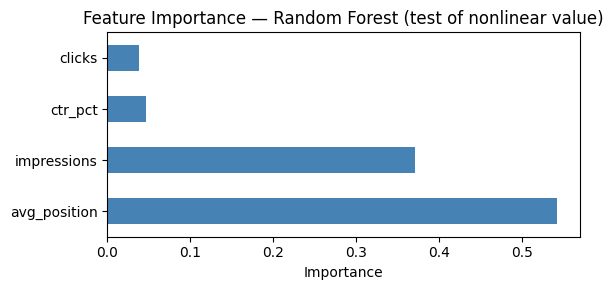


=== 3 False Negatives (baseline=yes, model says no) ===


,impressions,avg_position,ctr_pct,baseline_score,rf_prob



=== 3 False Positives (baseline=no, model says yes) ===


,impressions,avg_position,ctr_pct,baseline_score,rf_prob


In [27]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
# ------------------------------------------------------------------
# What does the model lean on?
# ------------------------------------------------------------------
importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("Random Forest feature importances:")
print(importances)

plt.figure(figsize=(6, 3))
importances.plot(kind="barh", color="steelblue")
plt.title("Feature Importance — Random Forest (test of nonlinear value)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Concrete error cases
# ------------------------------------------------------------------
test_eval = model_df.iloc[test_idx].copy()
test_eval["logistic_prob"] = logistic_prob
test_eval["rf_prob"] = rf_prob

# False negatives: baseline says eligible, model strongly disagrees
false_neg = test_eval[
    (test_eval["eligible"] == 1) & (test_eval["rf_prob"] < 0.2)
].nsmallest(3, "rf_prob")

# False positives: baseline says no, model strongly agrees
false_pos = test_eval[
    (test_eval["eligible"] == 0) & (test_eval["rf_prob"] > 0.8)
].nlargest(3, "rf_prob")

print("\n=== 3 False Negatives (baseline=yes, model says no) ===")
display(false_neg[["impressions", "avg_position", "ctr_pct", "baseline_score", "rf_prob"]])

print("\n=== 3 False Positives (baseline=no, model says yes) ===")
display(false_pos[["impressions", "avg_position", "ctr_pct", "baseline_score", "rf_prob"]])

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.